In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
nltk.download("")


In [2]:
data=pd.read_csv("../data/amazon_alexa.tsv",sep='\t')
data.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [3]:
column_names=data.columns.values
column_names

array(['rating', 'date', 'variation', 'verified_reviews', 'feedback'],
      dtype=object)

In [4]:
data.shape


(3150, 5)

In [5]:
data.describe()

,rating,feedback
count,3150.000000,3150.000000
mean,4.463175,0.918413
std,1.068506,0.273778
min,1.000000,0.000000
25%,4.000000,1.000000
50%,5.000000,1.000000
75%,5.000000,1.000000
max,5.000000,1.000000


In [6]:
# checking for null values
data.isna().sum()

rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64

In [7]:
data[data["verified_reviews"].isna()==True]

,rating,date,variation,verified_reviews,feedback
473,2,29-Jun-18,White,NaN,0


In [8]:
# removed null values
data=data.dropna()
data.isnull().sum()

rating              0
date                0
variation           0
verified_reviews    0
feedback            0
dtype: int64

In [9]:
print("The dataset shape after removing null values is",data.shape)

The dataset shape after removing null values is (3149, 5)


In [10]:
#creating a new column that contains the length of the string in the verified reviews column
data["length"]=data["verified_reviews"].apply(len)
data.head()

,rating,date,variation,verified_reviews,feedback,length
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1,13
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1,9
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1,195
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1,172
4,5,31-Jul-18,Charcoal Fabric,Music,1,5


In [11]:
#checking if the values in length column is accurate
print(f"'verified_review' column value:{data.iloc[9]["verified_reviews"]}")
print(f"Length of the review:{len(data.iloc[9]["verified_reviews"])}")
print(f"'length' column value:{data.iloc[9]["length"]}")

'verified_review' column value:Love it! I’ve listened to songs I haven’t heard since childhood! I get the news, weather, information! It’s great!
Length of the review:114
'length' column value:114


In [12]:
data.dtypes

rating               int64
date                object
variation           object
verified_reviews    object
feedback             int64
length               int64
dtype: object

In [13]:
#analysing rating column
data["rating"].value_counts()

rating
5    2286
4     455
1     161
3     152
2      95
Name: count, dtype: int64

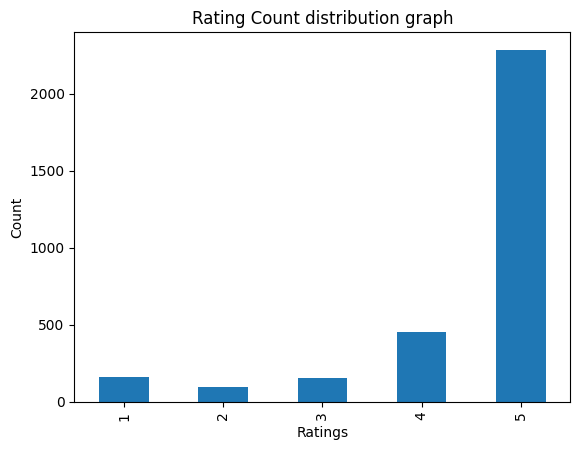

In [14]:
#rating distribution graph
rating_counts=data["rating"].value_counts().sort_index()
rating_counts
rating_counts.plot(kind="bar")
plt.xlabel("Ratings")
plt.ylabel("Count")
plt.title("Rating Count distribution graph")
plt.show()

In [15]:
#calculating the rating count distribution percentage
print(f"Rating values distribution in percentage:{round(data['rating'].value_counts()/data.shape[0]*100,2)}")

Rating values distribution in percentage:rating
5    72.59
4    14.45
1     5.11
3     4.83
2     3.02
Name: count, dtype: float64


In [16]:
rating_counts_percent=round(data['rating'].value_counts()/data.shape[0]*100,2)
df1=pd.DataFrame(rating_counts_percent)
df1.head()

,count
rating,
5,72.59
4,14.45
1,5.11
3,4.83
2,3.02


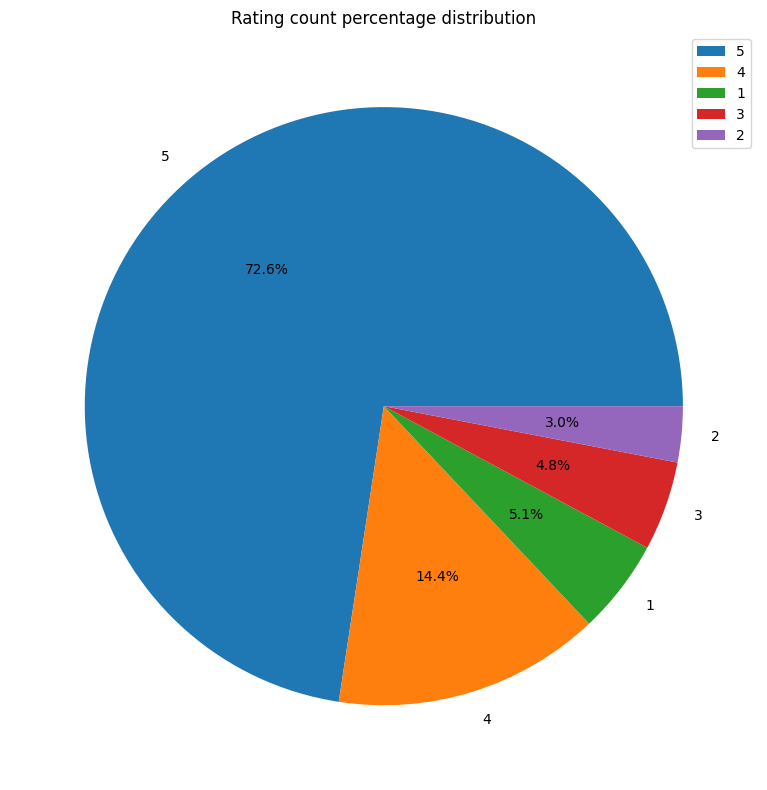

In [17]:
plt.figure(figsize=(14,8))
plt.pie(rating_counts_percent,labels=rating_counts_percent.index,autopct="%1.1f%%")
plt.title("Rating count percentage distribution")
plt.tight_layout()
plt.legend(loc='upper right')
plt.show()

In [18]:
#analysing feedback column
print(f"Feedback column value counts: \n{data['feedback'].value_counts()}")

Feedback column value counts: 
feedback
1    2893
0     256
Name: count, dtype: int64


In [19]:
# 0 means negative feedback and 1 means positive feedback

In [20]:
feedback_counts=data["feedback"].value_counts()
df2=pd.DataFrame(feedback_counts)
df2.head()

,count
feedback,
1,2893
0,256


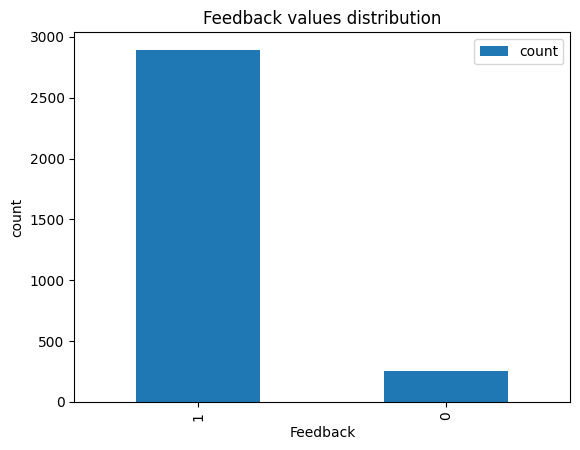

In [21]:
#feedback column values distribution
df2.plot(kind="bar")
plt.xlabel("Feedback")
plt.ylabel("count")
plt.title("Feedback values distribution")
plt.show()

In [22]:
#calculating the feedback count distribution percentage
print(f"feedback values distribution in percentage:{round(data['feedback'].value_counts()/data.shape[0]*100,2)}")

feedback values distribution in percentage:feedback
1    91.87
0     8.13
Name: count, dtype: float64


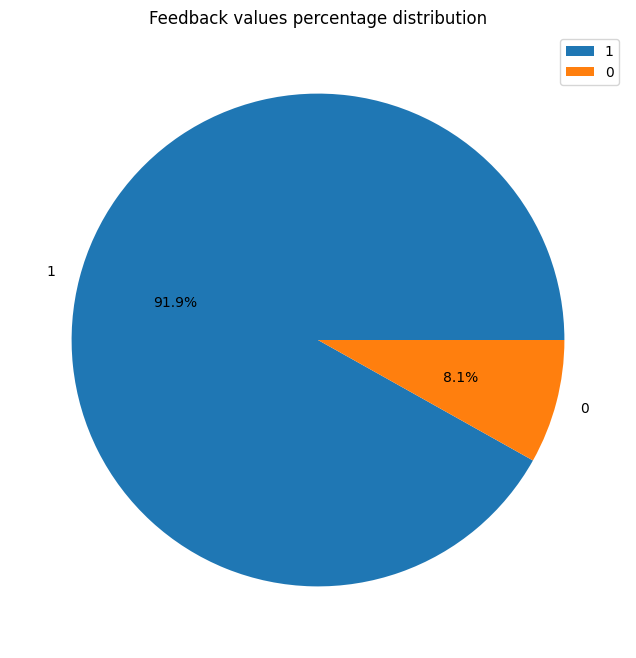

In [23]:
#feedback column values percent distribution
feedback_counts_percent=round(data['feedback'].value_counts()/data.shape[0]*100,2)
plt.figure(figsize=(15,8))
plt.pie(feedback_counts_percent.values,labels=feedback_counts_percent.index,autopct="%1.1f%%")
plt.legend()
plt.title("Feedback values percentage distribution")
plt.show()

In [24]:
#rating values for different values of feedback
data[data["feedback"]==0]["rating"].value_counts()

rating
1    161
2     95
Name: count, dtype: int64

In [25]:
data[data["feedback"]==1]["rating"].value_counts()

rating
5    2286
4     455
3     152
Name: count, dtype: int64

In [26]:
# rating of 1 and 2 are considered negative reviews and rating of 4,5 are considered as positive reviews. 3 as neutral

In [27]:
#analysing variation column
data["variation"].value_counts()

variation
Black  Dot                      516
Charcoal Fabric                 430
Configuration: Fire TV Stick    350
Black  Plus                     270
Black  Show                     265
Black                           261
Black  Spot                     241
White  Dot                      184
Heather Gray Fabric             157
White  Spot                     109
Sandstone Fabric                 90
White                            90
White  Show                      85
White  Plus                      78
Oak Finish                       14
Walnut Finish                     9
Name: count, dtype: int64

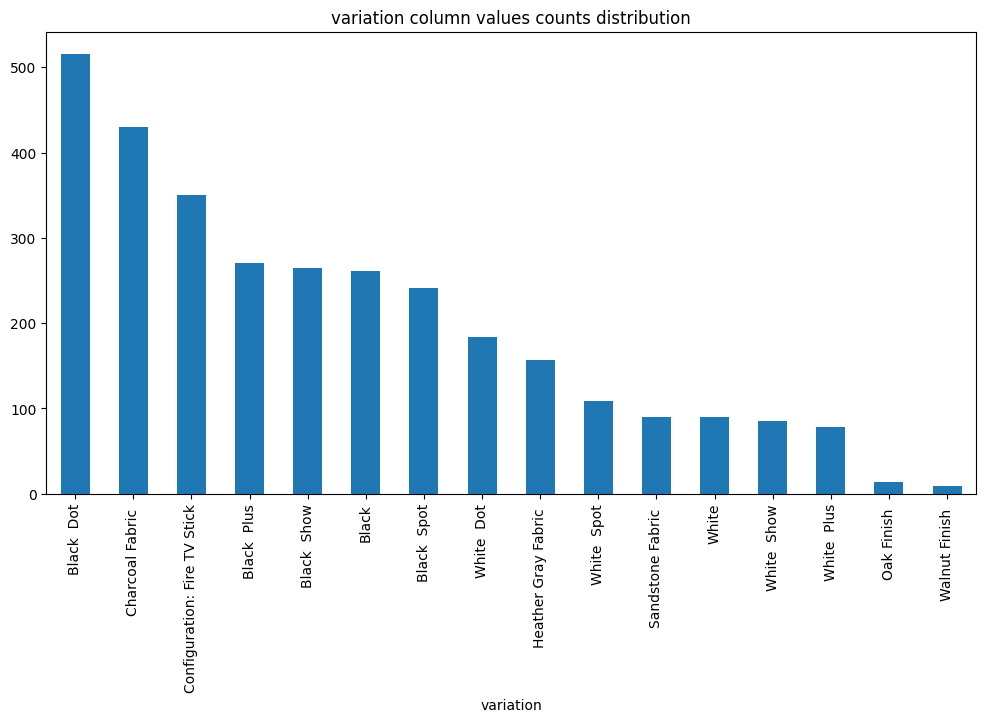

In [28]:
plt.figure(figsize=(12,6))
variation_counts=data["variation"].value_counts()
variation_counts.plot(kind="bar",x=variation_counts.index,y=variation_counts.values)
plt.title("variation column values counts distribution")
plt.show()

In [29]:
#variation vs rating
data.groupby("variation")["rating"].mean()

variation
Black                           4.233716
Black  Dot                      4.453488
Black  Plus                     4.370370
Black  Show                     4.490566
Black  Spot                     4.311203
Charcoal Fabric                 4.730233
Configuration: Fire TV Stick    4.591429
Heather Gray Fabric             4.694268
Oak Finish                      4.857143
Sandstone Fabric                4.355556
Walnut Finish                   4.888889
White                           4.166667
White  Dot                      4.423913
White  Plus                     4.358974
White  Show                     4.282353
White  Spot                     4.311927
Name: rating, dtype: float64

Text(0.5, 1.0, 'Distribution of length of review')

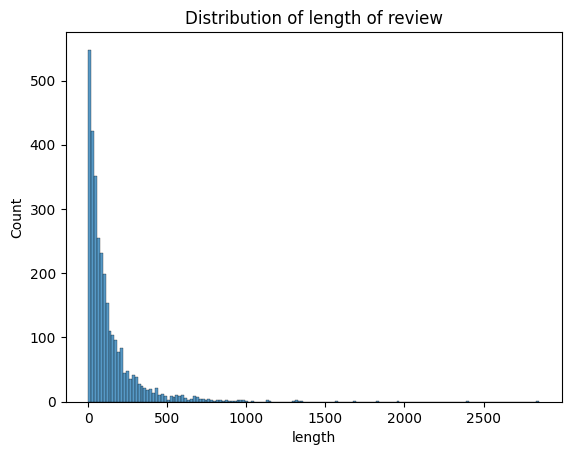

In [30]:
#analysing verified reviews column
sns.histplot(data["length"])
plt.title("Distribution of length of review")

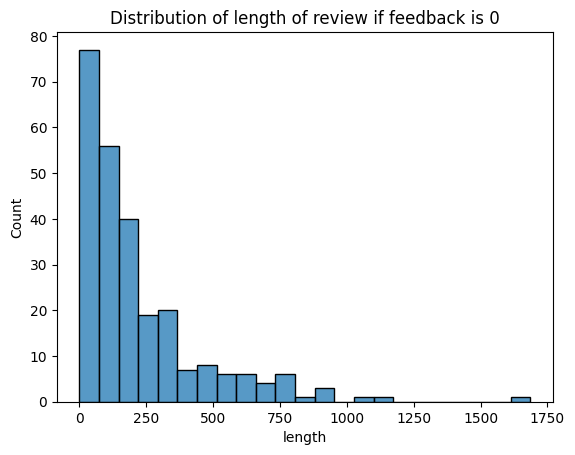

In [33]:
#distribution of length of review if feedback=0
sns.histplot(data[data["feedback"]==0]["length"])
plt.title("Distribution of length of review if feedback is 0")
plt.show()

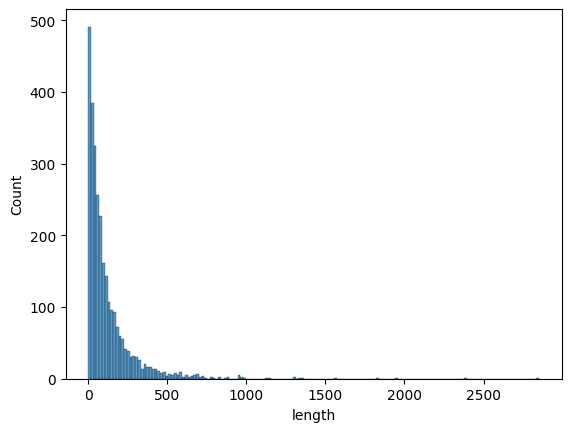

In [36]:
#distrbution of length of review if feedback is 1
sns.histplot(data[data["feedback"]==1]["length"])
plt.show("Distribution of length of reviews if feedback is 1")
plt.show()

In [ ]:
#the length of the reviews are shorted when the feedback=0 comparatively.

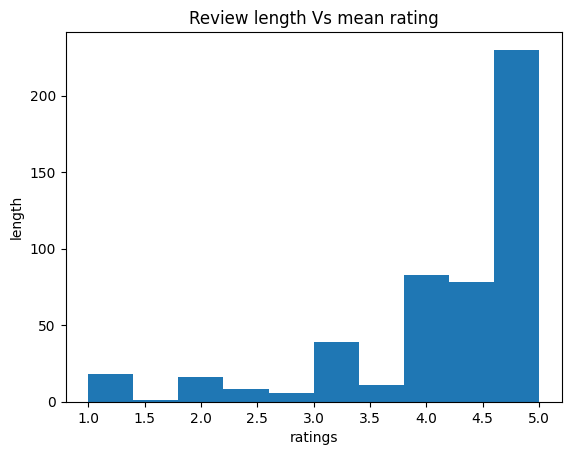

In [31]:
#length vs rating
data.groupby('length')["rating"].mean().plot.hist()
plt.title("Review length Vs mean rating")
plt.xlabel("ratings")
plt.ylabel("length")
plt.show()

In [ ]:
#users writes lenghty reviews for positive and a much shorter for negative

In [ ]:
#vectorising
cv=CountVectorizer(stop)